# **Fundamentos de Aprendizaje por Refuerzo**
## ***Regresión Lineal Múltiple***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Cargar el dataset

In [2]:
# Cargar el conjunto de datos
data = pd.read_csv(filepath_or_buffer='https://raw.githubusercontent.com/cdavid2804/test-1/main/Housing.csv')
print(np.shape(data))
data.head(10)

(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### Dividir los datos

In [3]:

# Se usaran caracteristicas numericas de tabla
X = data[['area','bedrooms','bathrooms','stories','parking']]
y = data['price']
X = X.values
y = y.values
X = np.hstack((np.ones((X.shape[0],1)),X))
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=  0.7)
print("Training data:", np.shape(X_train))
print("Test data:", np.shape(X_test))



Training data: (381, 6)
Test data: (164, 6)


## Modelo de regresión lineal múltiple
El modelo de regresión lineal tiene la forma:

$$ \hat{y} = \beta_0 + \beta_{1}*x_{1} + \beta_{2}*x_{2} + ... + \beta_{n}*x_{n} $$

$$\hat{y}=X\beta$$

Donde $\hat{y}$ es la predicción que queremos hacer

$\beta_0$ es el término independiente

$\beta_{n}$ es un vector de coeficientes

$x_{n}$ son los valores de las variables independientes del dataset.

El objetivo es obtener $\beta_0$ y $\beta_{n}$  tales que error cuadrático (residuo) , definido como:

$$RSS = \varepsilon_i^2 = \sum\limits_{i=1}^n(y_{i} - \hat{y})^2$$

Sea el mínimo.

Para ello se tiene que resolver la siguiente ecuación:

$$\beta = (X^TX)^{-1}X^Ty$$
$$\hat{y} = X(X^TX)^{-1}X^Ty $$

### Calcular los coeficientes

In [4]:
def coeficientes(X, y):
  X_T = np.transpose(X)
  betas = np.linalg.inv(X_T @ X) @ X_T @ y
  return betas

In [5]:
betas = coeficientes(X_train, y_train)
print(f"Betas: {betas}")

Betas: [-1.83889775e+05  3.52036016e+02  1.81562320e+05  1.04849929e+06
  5.53361848e+05  3.73861342e+05]


### Hacer predicciones

In [6]:
y_preb = np.sum(betas * X_test, axis = 1)
print(f"Predicciones: {y_preb[0:20]}")
print(f"Real: {y_test[0:20]}")

Predicciones: [3390565.90194684 3118832.86630902 4440160.77376703 4421238.18553403
 3055466.38342363 3271137.42852216 5417462.24951936 3391307.83535828
 4083107.98952214 5196683.65392887 7883217.95806691 7654519.85685851
 5452135.67619669 4296529.1718689  5630305.57640303 5206905.94319618
 3555582.52947435 3295554.03899814 5906299.99825468 6277697.99516625]
Real: [2961000 3045000 4382000 2835000 1750000 3290000 6510000 3500000 1960000
 5285000 8080940 9681000 7455000 3290000 7420000 6160000 4200000 2450000
 5530000 8680000]


### Graficar las predicciones y valores reales

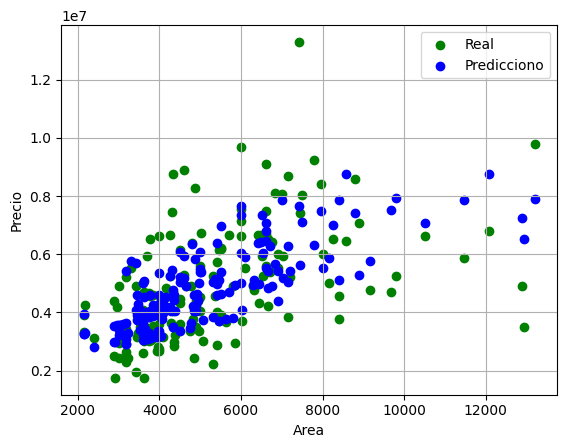

In [7]:
plt.scatter(X_test[:,1], y_test, c = "green", label = "Real")
plt.scatter(X_test[:,1], y_preb, c = "blue", label = "Predicciono")
plt.xlabel("Area")
plt.ylabel("Precio")
plt.grid()
plt.legend()

### Evaluacion del modelo

In [8]:
rss = np.sum((y_test - y_preb)**2)
tss = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (rss/tss)
print(f"Coeficientes R2: {r2}")

Coeficientes R2: 0.5160201860512243
